# 02 - Data Cleaning

## Missing Value Analysis

**Objective:** Investigate the amount, pattern, and continuity of missing values before deciding how they should be handled.

In [84]:
# Import pandas for data analysis
import pandas as pd

In [85]:
# Locate the raw dataset
from pathlib import Path

possible_paths = [
    Path("data/raw/household_power_consumption.txt"),
    Path("../data/raw/household_power_consumption.txt")
]

file_path = next((path for path in possible_paths if path.exists()), None)

if file_path is None:
    raise FileNotFoundError("Raw dataset not found.")

print("Dataset path:", file_path)

Dataset path: ..\data\raw\household_power_consumption.txt


In [86]:
# Load raw data and convert '?' to missing values
df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Dataset loaded:", df.shape)

Dataset loaded: (2075259, 9)


In [87]:
# Define electrical measurement columns
measurement_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

In [88]:
# Count missing values in each column
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2)
})

missing_summary

,missing_count,missing_percentage
Date,0,0.00
Time,0,0.00
Global_active_power,25979,1.25
Global_reactive_power,25979,1.25
Voltage,25979,1.25
Global_intensity,25979,1.25
Sub_metering_1,25979,1.25
Sub_metering_2,25979,1.25
Sub_metering_3,25979,1.25


In [89]:
# Count rows where all measurements are missing
all_missing_mask = df[measurement_cols].isna().all(axis=1)

all_missing_count = all_missing_mask.sum()

print("Rows with all measurements missing:", all_missing_count)

Rows with all measurements missing: 25979


In [90]:
# Count rows with at least one missing measurement
any_missing_mask = df[measurement_cols].isna().any(axis=1)

any_missing_count = any_missing_mask.sum()

print("Rows with any measurement missing:", any_missing_count)

Rows with any measurement missing: 25979


In [91]:
# Count rows with only partial measurement missingness
partial_missing_count = (
    any_missing_mask & ~all_missing_mask
).sum()

print("Partially missing measurement rows:", partial_missing_count)

Partially missing measurement rows: 0


In [92]:
# Display first missing measurement records
df.loc[all_missing_mask].head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6840,21/12/2006,11:24:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19724,30/12/2006,10:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19725,30/12/2006,10:09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41832,14/1/2007,18:36:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61909,28/1/2007,17:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98254,22/2/2007,22:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98255,22/2/2007,22:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
142588,25/3/2007,17:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190497,28/4/2007,00:21:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
# Calculate percentage of rows with missing measurements
missing_row_percentage = (
    all_missing_count / len(df) * 100
)

print(f"Missing measurement rows: {missing_row_percentage:.2f}%")

Missing measurement rows: 1.25%


In [94]:
# Create groups for consecutive missing/non-missing rows
group_id = all_missing_mask.ne(
    all_missing_mask.shift()
).cumsum()

In [95]:
# Calculate length of each consecutive missing run
missing_runs = (
    all_missing_mask[all_missing_mask]
    .groupby(group_id[all_missing_mask])
    .size()
)

print("Number of missing runs:", len(missing_runs))

Number of missing runs: 71


In [96]:
# Summarize consecutive missing run lengths
missing_runs.describe()

count      71.000000
mean      365.901408
std      1251.468043
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      7226.000000
dtype: float64

In [97]:
# Display the ten longest missing runs
missing_runs.sort_values(
    ascending=False
).head(10)

138    7226
140    5237
14     3723
100    3305
118    3129
126    2027
104     891
32       83
78       70
34       47
dtype: int64

In [98]:
# Build a table describing each missing period
missing_run_table = (
    df.loc[all_missing_mask, ["Date", "Time"]]
    .assign(run_id=group_id[all_missing_mask].values)
    .groupby("run_id")
    .agg(
        start_date=("Date", "first"),
        start_time=("Time", "first"),
        end_date=("Date", "last"),
        end_time=("Time", "last"),
        missing_rows=("Date", "size")
    )
)

missing_run_table.head()

,start_date,start_time,end_date,end_time,missing_rows
run_id,,,,,
2,21/12/2006,11:23:00,21/12/2006,11:24:00,2
4,30/12/2006,10:08:00,30/12/2006,10:09:00,2
6,14/1/2007,18:36:00,14/1/2007,18:36:00,1
8,28/1/2007,17:13:00,28/1/2007,17:13:00,1
10,22/2/2007,22:58:00,22/2/2007,22:59:00,2


In [99]:
# Display the largest missing periods
missing_run_table.sort_values(
    "missing_rows",
    ascending=False
).head(10)

,start_date,start_time,end_date,end_time,missing_rows
run_id,,,,,
138,17/8/2010,21:02:00,22/8/2010,21:27:00,7226
140,25/9/2010,03:56:00,28/9/2010,19:12:00,5237
14,28/4/2007,00:21:00,30/4/2007,14:23:00,3723
100,13/6/2009,00:30:00,15/6/2009,07:34:00,3305
118,12/1/2010,14:53:00,14/1/2010,19:01:00,3129
126,20/3/2010,03:52:00,21/3/2010,13:38:00,2027
104,13/8/2009,05:00:00,13/8/2009,19:50:00,891
32,15/7/2007,16:49:00,15/7/2007,18:11:00,83
78,10/12/2008,10:48:00,10/12/2008,11:57:00,70


In [100]:
# Compare valid and missing measurement records
valid_rows = (~all_missing_mask).sum()

print("Total rows:", len(df))
print("Valid measurement rows:", valid_rows)
print("Missing measurement rows:", all_missing_count)

Total rows: 2075259
Valid measurement rows: 2049280
Missing measurement rows: 25979


## Missing Value Findings

- `Date` and `Time` contain no missing values.
- Each of the seven electrical measurement columns contains 25,979 missing values.
- Missing measurements represent approximately 1.25% of the dataset.
- Missingness occurs across complete measurement rows rather than isolated individual measurement columns.
- Consecutive missing periods were investigated to determine whether gaps are short or long.
- Missing values have not yet been filled or removed.

### Cleaning Consideration

Short and long missing periods should not automatically receive the same treatment.

Small gaps may potentially be interpolated, while long gaps require more careful handling to avoid creating unrealistic synthetic energy-consumption patterns.

## Missing Value Handling

A conservative missing-value strategy is applied:

- Short missing periods of 5 minutes or less are interpolated.
- Longer missing periods are retained as missing values.
- Timestamp rows are preserved to maintain the original time-series structure.
- The raw dataset is not modified.

In [101]:
# Define the maximum gap allowed for interpolation
SHORT_GAP_LIMIT = 5

print("Short-gap limit:", SHORT_GAP_LIMIT, "minutes")

Short-gap limit: 5 minutes


In [102]:
# Separate short and long missing periods
short_run_ids = missing_runs[
    missing_runs <= SHORT_GAP_LIMIT
].index

long_run_ids = missing_runs[
    missing_runs > SHORT_GAP_LIMIT
].index

print("Short missing runs:", len(short_run_ids))
print("Long missing runs:", len(long_run_ids))

Short missing runs: 55
Long missing runs: 16


In [103]:
# Mark rows belonging to short and long gaps
short_gap_mask = (
    all_missing_mask &
    group_id.isin(short_run_ids)
)

long_gap_mask = (
    all_missing_mask &
    group_id.isin(long_run_ids)
)

print("Rows in short gaps:", short_gap_mask.sum())
print("Rows in long gaps:", long_gap_mask.sum())

Rows in short gaps: 76
Rows in long gaps: 25903


In [104]:
# Create a copy for cleaning
df_clean = df.copy()

print("Cleaning copy created:", df_clean.shape)

Cleaning copy created: (2075259, 9)


In [105]:
# Generate interpolation only between valid observations
interpolated_values = (
    df_clean[measurement_cols]
    .interpolate(
        method="linear",
        limit_area="inside"
    )
)

In [106]:
# Fill only missing rows belonging to short gaps
df_clean.loc[
    short_gap_mask,
    measurement_cols
] = interpolated_values.loc[
    short_gap_mask,
    measurement_cols
]

In [107]:
# Check missing values after short-gap interpolation
remaining_missing = df_clean.isna().sum()

remaining_missing

Date                         0
Time                         0
Global_active_power      25903
Global_reactive_power    25903
Voltage                  25903
Global_intensity         25903
Sub_metering_1           25903
Sub_metering_2           25903
Sub_metering_3           25903
dtype: int64

In [108]:
# Count rows successfully interpolated
interpolated_row_count = (
    df.loc[short_gap_mask, measurement_cols]
    .isna()
    .all(axis=1)
    &
    df_clean.loc[short_gap_mask, measurement_cols]
    .notna()
    .all(axis=1)
).sum()

print("Rows interpolated:", interpolated_row_count)

Rows interpolated: 76


In [109]:
# Confirm long missing gaps remain untouched
long_gap_remaining = (
    df_clean.loc[long_gap_mask, measurement_cols]
    .isna()
    .all(axis=1)
    .sum()
)

print("Long-gap rows still missing:", long_gap_remaining)
print("Expected long-gap rows:", long_gap_mask.sum())

Long-gap rows still missing: 25903
Expected long-gap rows: 25903


In [110]:
# Compare missing values before and after cleaning
missing_comparison = pd.DataFrame({
    "before": df[measurement_cols].isna().sum(),
    "after": df_clean[measurement_cols].isna().sum()
})

missing_comparison["handled"] = (
    missing_comparison["before"] -
    missing_comparison["after"]
)

missing_comparison

,before,after,handled
Global_active_power,25979,25903,76
Global_reactive_power,25979,25903,76
Voltage,25979,25903,76
Global_intensity,25979,25903,76
Sub_metering_1,25979,25903,76
Sub_metering_2,25979,25903,76
Sub_metering_3,25979,25903,76


In [111]:
# Display a few interpolated records
df_clean.loc[
    short_gap_mask,
    ["Date", "Time"] + measurement_cols
].head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
6839,21/12/2006,11:23:00,0.244667,0.000000,242.106667,1.000000,0.000000,0.0,0.000000
6840,21/12/2006,11:24:00,0.245333,0.000000,241.923333,1.000000,0.000000,0.0,0.000000
19724,30/12/2006,10:08:00,6.417333,0.402000,237.230000,27.066667,37.666667,22.0,17.666667
19725,30/12/2006,10:09:00,6.616667,0.390000,237.060000,27.933333,37.333333,25.0,17.333333
41832,14/1/2007,18:36:00,3.213000,0.257000,233.000000,13.800000,0.000000,0.0,16.500000
61909,28/1/2007,17:13:00,2.221000,0.276000,235.600000,9.400000,0.000000,0.5,16.000000
98254,22/2/2007,22:58:00,3.662667,0.083333,236.210000,15.400000,0.000000,12.0,17.000000
98255,22/2/2007,22:59:00,4.279333,0.106667,236.200000,18.000000,0.000000,24.0,17.000000
142588,25/3/2007,17:52:00,0.529000,0.228000,242.595000,2.300000,0.000000,0.0,0.000000
240590,1/6/2007,19:14:00,0.452000,0.163000,234.810000,2.100000,0.000000,0.0,0.000000


In [112]:
# Compare original and cleaned values for short gaps
comparison = pd.concat(
    [
        df.loc[short_gap_mask, measurement_cols]
          .head(5)
          .add_prefix("original_"),

        df_clean.loc[short_gap_mask, measurement_cols]
          .head(5)
          .add_prefix("cleaned_")
    ],
    axis=1
)

comparison

,original_Global_active_power,original_Global_reactive_power,original_Voltage,original_Global_intensity,original_Sub_metering_1,original_Sub_metering_2,original_Sub_metering_3,cleaned_Global_active_power,cleaned_Global_reactive_power,cleaned_Voltage,cleaned_Global_intensity,cleaned_Sub_metering_1,cleaned_Sub_metering_2,cleaned_Sub_metering_3
6839,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.244667,0.000,242.106667,1.000000,0.000000,0.0,0.000000
6840,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.245333,0.000,241.923333,1.000000,0.000000,0.0,0.000000
19724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.417333,0.402,237.230000,27.066667,37.666667,22.0,17.666667
19725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.616667,0.390,237.060000,27.933333,37.333333,25.0,17.333333
41832,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.213000,0.257,233.000000,13.800000,0.000000,0.0,16.500000


### Missing Value Treatment Summary

- Missing measurement records were separated into short and long consecutive gaps.
- Gaps of 5 minutes or less were treated using linear interpolation.
- Interpolation was restricted to values located between valid observations.
- Long missing periods were intentionally retained rather than generating large amounts of synthetic electricity data.
- No timestamp records were deleted.
- The original raw dataset remains unchanged.
- Further handling of long gaps can be considered during downstream preprocessing or model-specific preparation.

## Duplicate Analysis and Handling

**Objective:** Identify exact duplicate records and repeated timestamp records before deciding whether any rows should be removed.

In [113]:
# Count fully identical rows
exact_duplicates = df_clean.duplicated().sum()

print("Exact duplicate rows:", exact_duplicates)

Exact duplicate rows: 0


In [114]:
# Count repeated Date-Time combinations
timestamp_duplicates = df_clean.duplicated(
    subset=["Date", "Time"]
).sum()

print("Duplicate timestamps:", timestamp_duplicates)

Duplicate timestamps: 0


In [115]:
# Display exact duplicate rows
duplicate_rows = df_clean[
    df_clean.duplicated(keep=False)
]

duplicate_rows.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3


In [116]:
# Display rows sharing the same timestamp
duplicate_timestamp_rows = df_clean[
    df_clean.duplicated(
        subset=["Date", "Time"],
        keep=False
    )
]

duplicate_timestamp_rows.head(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3


In [117]:
# Remove exact duplicate records only
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after = len(df_clean)

print("Rows before:", rows_before)
print("Rows after:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before: 2075259
Rows after: 2075259
Duplicates removed: 0


In [118]:
# Confirm no exact duplicates remain
remaining_duplicates = df_clean.duplicated().sum()

print("Remaining exact duplicates:", remaining_duplicates)

Remaining exact duplicates: 0


In [119]:
# Recheck repeated timestamps after duplicate handling
remaining_timestamp_duplicates = df_clean.duplicated(
    subset=["Date", "Time"]
).sum()

print(
    "Remaining duplicate timestamps:",
    remaining_timestamp_duplicates
)

Remaining duplicate timestamps: 0


### Duplicate Analysis Findings

- Exact duplicate records were checked.
- Duplicate `Date` and `Time` combinations were also checked separately.
- No exact duplicate records were found.
- No repeated timestamp records were found.
- Therefore, no rows required removal during duplicate handling.
- The dataset row count remained unchanged after this step.

## Invalid and Inconsistent Value Checking

**Objective:** Check the electrical measurement columns for non-numeric values, infinite values, negative values, and other obvious inconsistencies before outlier analysis.

In [120]:
# Check current column data types
df_clean.dtypes

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [121]:
# Check whether measurement columns contain numeric data
non_numeric_summary = {}

for column in measurement_cols:
    converted = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

    non_numeric_count = (
        converted.isna().sum()
        - df_clean[column].isna().sum()
    )

    non_numeric_summary[column] = non_numeric_count

pd.Series(
    non_numeric_summary,
    name="non_numeric_values"
)

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Name: non_numeric_values, dtype: int64

In [122]:
# Import NumPy for numeric validation
import numpy as np

In [123]:
# Count positive and negative infinity values
infinite_summary = pd.DataFrame({
    "positive_infinity": [
        np.isposinf(df_clean[col]).sum()
        for col in measurement_cols
    ],
    "negative_infinity": [
        np.isneginf(df_clean[col]).sum()
        for col in measurement_cols
    ]
}, index=measurement_cols)

infinite_summary

,positive_infinity,negative_infinity
Global_active_power,0,0
Global_reactive_power,0,0
Voltage,0,0
Global_intensity,0,0
Sub_metering_1,0,0
Sub_metering_2,0,0
Sub_metering_3,0,0


In [124]:
# Count negative values in each measurement column
negative_summary = pd.Series(
    {
        column: (df_clean[column] < 0).sum()
        for column in measurement_cols
    },
    name="negative_values"
)

negative_summary

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Name: negative_values, dtype: int64

In [125]:
# Display rows containing any negative measurement
negative_mask = (
    df_clean[measurement_cols] < 0
).any(axis=1)

df_clean.loc[
    negative_mask,
    ["Date", "Time"] + measurement_cols
].head(20)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3


In [126]:
# Count zero values without treating them as invalid
zero_summary = pd.Series(
    {
        column: (df_clean[column] == 0).sum()
        for column in measurement_cols
    },
    name="zero_values"
)

zero_summary

Global_active_power            0
Global_reactive_power     481569
Voltage                        0
Global_intensity               0
Sub_metering_1           1880238
Sub_metering_2           1436874
Sub_metering_3            852117
Name: zero_values, dtype: int64

In [127]:
# Review minimum and maximum values
range_summary = pd.DataFrame({
    "minimum": df_clean[measurement_cols].min(),
    "maximum": df_clean[measurement_cols].max()
})

range_summary

,minimum,maximum
Global_active_power,0.076,11.122
Global_reactive_power,0.000,1.390
Voltage,223.200,254.150
Global_intensity,0.200,48.400
Sub_metering_1,0.000,88.000
Sub_metering_2,0.000,80.000
Sub_metering_3,0.000,31.000


In [128]:
# Count non-finite values in measurement columns
non_finite_summary = pd.Series(
    {
        column: (
            ~np.isfinite(
                df_clean[column].dropna()
            )
        ).sum()
        for column in measurement_cols
    },
    name="non_finite_values"
)

non_finite_summary

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Name: non_finite_values, dtype: int64

In [129]:
# Combine invalid-value checks into one table
invalid_value_summary = pd.DataFrame({
    "non_numeric": pd.Series(non_numeric_summary),
    "negative": negative_summary,
    "non_finite": non_finite_summary,
    "zero_values": zero_summary,
    "minimum": df_clean[measurement_cols].min(),
    "maximum": df_clean[measurement_cols].max()
})

invalid_value_summary

,non_numeric,negative,non_finite,zero_values,minimum,maximum
Global_active_power,0,0,0,0,0.076,11.122
Global_reactive_power,0,0,0,481569,0.000,1.390
Voltage,0,0,0,0,223.200,254.150
Global_intensity,0,0,0,0,0.200,48.400
Sub_metering_1,0,0,0,1880238,0.000,88.000
Sub_metering_2,0,0,0,1436874,0.000,80.000
Sub_metering_3,0,0,0,852117,0.000,31.000


In [130]:
# Identify rows containing clear numeric invalidities
clear_invalid_mask = pd.Series(
    False,
    index=df_clean.index
)

for column in measurement_cols:
    clear_invalid_mask |= np.isinf(
        df_clean[column].fillna(0)
    )

print(
    "Rows with clear invalid numeric values:",
    clear_invalid_mask.sum()
)

Rows with clear invalid numeric values: 0


### Invalid and Inconsistent Value Findings

- All electrical measurement columns were checked for unexpected non-numeric values.
- No positive or negative infinite values were found.
- Negative measurement values were checked separately.
- Zero values were retained because zero consumption or zero sub-metering can represent valid observations.
- Minimum and maximum values were reviewed, but extreme values were not removed at this stage.
- Potential extreme observations will be investigated separately during outlier analysis.
- No arbitrary domain thresholds were applied without supporting evidence.

## Datetime Handling

**Objective:** Combine the separate `Date` and `Time` columns into a valid datetime field and verify that all timestamps can be parsed correctly.

Chronological sorting and time-frequency validation are intentionally left for the pipeline and validation stage.

In [131]:
# Preview the original date and time values
df_clean[["Date", "Time"]].head()

,Date,Time
0,16/12/2006,17:24:00
1,16/12/2006,17:25:00
2,16/12/2006,17:26:00
3,16/12/2006,17:27:00
4,16/12/2006,17:28:00


In [132]:
# Check current Date and Time data types
df_clean[["Date", "Time"]].dtypes

Date    str
Time    str
dtype: object

In [133]:
# Combine Date and Time as a single text timestamp
datetime_text = (
    df_clean["Date"].astype(str)
    + " "
    + df_clean["Time"].astype(str)
)

datetime_text.head()

0    16/12/2006 17:24:00
1    16/12/2006 17:25:00
2    16/12/2006 17:26:00
3    16/12/2006 17:27:00
4    16/12/2006 17:28:00
dtype: str

In [134]:
# Convert combined values into proper datetime format
parsed_timestamp = pd.to_datetime(
    datetime_text,
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

In [135]:
# Count timestamps that failed datetime conversion
invalid_timestamp_count = parsed_timestamp.isna().sum()

print("Invalid timestamps:", invalid_timestamp_count)

Invalid timestamps: 0


In [136]:
# Display records with invalid timestamps
invalid_timestamp_rows = df_clean.loc[
    parsed_timestamp.isna(),
    ["Date", "Time"]
]

invalid_timestamp_rows.head(20)

,Date,Time


In [137]:
# Add the validated datetime column
df_clean["Timestamp"] = parsed_timestamp

df_clean[
    ["Date", "Time", "Timestamp"]
].head()

,Date,Time,Timestamp
0,16/12/2006,17:24:00,2006-12-16 17:24:00
1,16/12/2006,17:25:00,2006-12-16 17:25:00
2,16/12/2006,17:26:00,2006-12-16 17:26:00
3,16/12/2006,17:27:00,2006-12-16 17:27:00
4,16/12/2006,17:28:00,2006-12-16 17:28:00


In [138]:
# Confirm the new timestamp data type
print(
    "Timestamp type:",
    df_clean["Timestamp"].dtype
)

Timestamp type: datetime64[us]


In [139]:
# Check the available time range
print(
    "Earliest timestamp:",
    df_clean["Timestamp"].min()
)

print(
    "Latest timestamp:",
    df_clean["Timestamp"].max()
)

Earliest timestamp: 2006-12-16 17:24:00
Latest timestamp: 2010-11-26 21:02:00


In [140]:
# Confirm every row has a valid timestamp
print(
    "Missing Timestamp values:",
    df_clean["Timestamp"].isna().sum()
)

Missing Timestamp values: 0


In [141]:
# Confirm datetime handling did not change row count
print("Rows after datetime handling:", len(df_clean))

Rows after datetime handling: 2075259


### Datetime Handling Findings

- The original dataset stores date and time in separate `Date` and `Time` columns.
- Both fields were combined into a new `Timestamp` column.
- The explicit format `%d/%m/%Y %H:%M:%S` was used to avoid ambiguous date parsing.
- All timestamps were converted successfully.
- No invalid or missing datetime values were produced.
- The original `Date` and `Time` columns were retained for traceability.
- No chronological sorting or frequency validation was performed because those tasks belong to the pipeline and validation stage.

## Outlier Analysis

**Objective:** Detect statistically unusual electrical measurements and inspect whether they appear to be data errors or potentially valid high/low consumption events.

Outliers are identified for investigation only. They are not automatically removed because genuine peak-demand events may be important for forecasting and anomaly-detection tasks.

In [142]:
# Review the columns used for outlier analysis
measurement_cols

['Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3']

In [143]:
# Calculate IQR-based outlier limits for each measurement
outlier_summary = []

for column in measurement_cols:
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_summary.append({
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_limit": lower_limit,
        "upper_limit": upper_limit
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,column,q1,q3,iqr,lower_limit,upper_limit
0,Global_active_power,0.308,1.528,1.220,-1.522,3.358
1,Global_reactive_power,0.048,0.194,0.146,-0.171,0.413
2,Voltage,238.990,242.890,3.900,233.140,248.740
3,Global_intensity,1.400,6.400,5.000,-6.100,13.900
4,Sub_metering_1,0.000,0.000,0.000,0.000,0.000
5,Sub_metering_2,0.000,1.000,1.000,-1.500,2.500
6,Sub_metering_3,0.000,17.000,17.000,-25.500,42.500


In [144]:
# Count observations outside the IQR limits
outlier_counts = []

for _, row in outlier_summary.iterrows():
    column = row["column"]

    mask = (
        (df_clean[column] < row["lower_limit"]) |
        (df_clean[column] > row["upper_limit"])
    )

    count = mask.sum()

    outlier_counts.append({
        "column": column,
        "outlier_count": count,
        "outlier_percentage": round(
            count / df_clean[column].notna().sum() * 100,
            2
        )
    })

outlier_counts = pd.DataFrame(outlier_counts)

outlier_counts

,column,outlier_count,outlier_percentage
0,Global_active_power,94919,4.63
1,Global_reactive_power,40425,1.97
2,Voltage,51068,2.49
3,Global_intensity,100973,4.93
4,Sub_metering_1,169118,8.25
5,Sub_metering_2,77166,3.77
6,Sub_metering_3,0,0.00


In [145]:
# Combine thresholds and outlier counts
outlier_report = outlier_summary.merge(
    outlier_counts,
    on="column"
)

outlier_report

,column,q1,q3,iqr,lower_limit,upper_limit,outlier_count,outlier_percentage
0,Global_active_power,0.308,1.528,1.220,-1.522,3.358,94919,4.63
1,Global_reactive_power,0.048,0.194,0.146,-0.171,0.413,40425,1.97
2,Voltage,238.990,242.890,3.900,233.140,248.740,51068,2.49
3,Global_intensity,1.400,6.400,5.000,-6.100,13.900,100973,4.93
4,Sub_metering_1,0.000,0.000,0.000,0.000,0.000,169118,8.25
5,Sub_metering_2,0.000,1.000,1.000,-1.500,2.500,77166,3.77
6,Sub_metering_3,0.000,17.000,17.000,-25.500,42.500,0,0.00


In [146]:
# Get IQR limits for Global_active_power
target_limits = outlier_report[
    outlier_report["column"] == "Global_active_power"
].iloc[0]

print("Lower limit:", target_limits["lower_limit"])
print("Upper limit:", target_limits["upper_limit"])

Lower limit: -1.522
Upper limit: 3.358


In [147]:
# Identify Global_active_power outlier candidates
active_power_outliers = df_clean[
    (df_clean["Global_active_power"] < target_limits["lower_limit"]) |
    (df_clean["Global_active_power"] > target_limits["upper_limit"])
]

print(
    "Global_active_power outlier candidates:",
    len(active_power_outliers)
)

Global_active_power outlier candidates: 94919


In [148]:
# Inspect the largest active-power observations
active_power_outliers[
    [
        "Timestamp",
        "Global_active_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].sort_values(
    "Global_active_power",
    ascending=False
).head(20)

,Timestamp,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1150545,2009-02-22 17:09:00,11.122,229.78,48.4,35.0,69.0,16.0
112450,2007-03-04 19:34:00,10.670,230.20,46.4,37.0,69.0,16.0
112449,2007-03-04 19:33:00,10.650,229.97,46.4,36.0,70.0,17.0
1150544,2009-02-22 17:08:00,10.536,230.24,45.8,23.0,69.0,16.0
1029775,2008-11-30 20:19:00,10.348,231.60,44.6,36.0,71.0,16.0
968160,2008-10-19 01:24:00,10.290,230.90,44.6,35.0,66.0,17.0
586200,2008-01-27 19:24:00,10.162,229.16,44.2,71.0,0.0,0.0
112448,2007-03-04 19:32:00,10.154,229.72,44.4,36.0,61.0,16.0
1029773,2008-11-30 20:17:00,10.074,231.41,43.4,36.0,70.0,16.0
968161,2008-10-19 01:25:00,10.064,231.48,43.4,36.0,69.0,17.0


In [149]:
# Inspect the smallest active-power observations
df_clean[
    [
        "Timestamp",
        "Global_active_power",
        "Voltage",
        "Global_intensity"
    ]
].sort_values(
    "Global_active_power"
).head(20)

,Timestamp,Global_active_power,Voltage,Global_intensity
894458,2008-08-28 21:02:00,0.076,235.64,0.2
894444,2008-08-28 20:48:00,0.076,234.88,0.2
894445,2008-08-28 20:49:00,0.076,234.34,0.2
894446,2008-08-28 20:50:00,0.076,234.06,0.2
894447,2008-08-28 20:51:00,0.076,234.03,0.2
894448,2008-08-28 20:52:00,0.076,233.92,0.2
894442,2008-08-28 20:46:00,0.076,235.18,0.2
894443,2008-08-28 20:47:00,0.076,235.40,0.2
871322,2008-08-12 19:26:00,0.076,236.50,0.2
863654,2008-08-07 11:38:00,0.078,237.44,0.2


In [150]:
# Import Matplotlib for outlier visualization
import matplotlib.pyplot as plt

C:\Users\Charith\AppData\Local\Temp\ipykernel_17604\2264868573.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


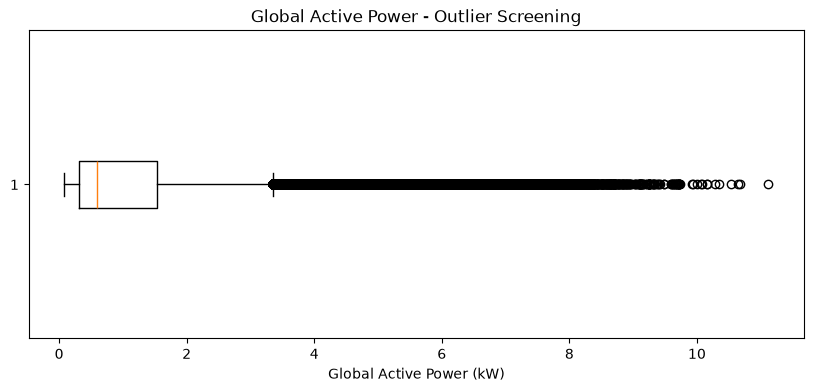

In [151]:
# Visualize the Global_active_power distribution
plt.figure(figsize=(10, 4))

plt.boxplot(
    df_clean["Global_active_power"].dropna(),
    vert=False
)

plt.xlabel("Global Active Power (kW)")
plt.title("Global Active Power - Outlier Screening")
plt.show()

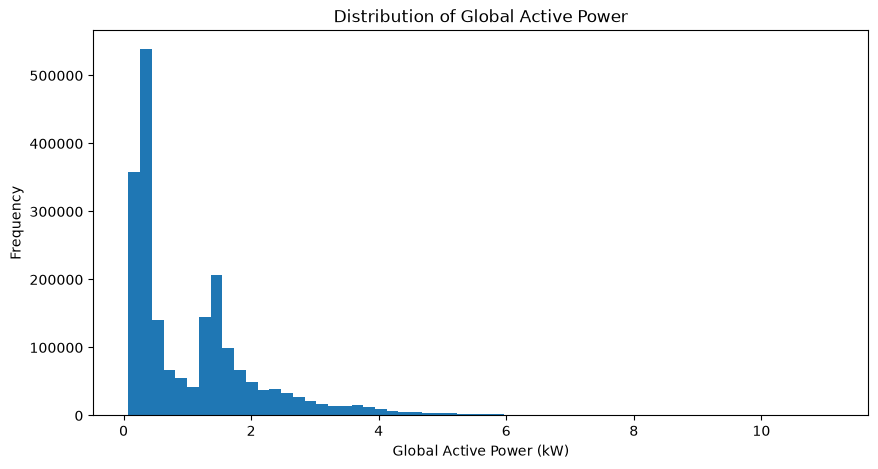

In [152]:
# Visualize the active-power value distribution
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean["Global_active_power"].dropna(),
    bins=60
)

plt.xlabel("Global Active Power (kW)")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")
plt.show()

In [153]:
# Display the five largest values in each measurement
for column in measurement_cols:
    print(f"\nTop values - {column}")
    print(
        df_clean[
            ["Timestamp", column]
        ]
        .nlargest(5, column)
        .to_string(index=False)
    )


Top values - Global_active_power
          Timestamp  Global_active_power
2009-02-22 17:09:00               11.122
2007-03-04 19:34:00               10.670
2007-03-04 19:33:00               10.650
2009-02-22 17:08:00               10.536
2008-11-30 20:19:00               10.348

Top values - Global_reactive_power
          Timestamp  Global_reactive_power
2008-04-13 18:44:00                  1.390
2008-04-13 18:43:00                  1.364
2008-04-13 18:29:00                  1.274
2009-10-24 17:20:00                  1.240
2008-04-13 17:57:00                  1.222

Top values - Voltage
          Timestamp  Voltage
2009-12-20 15:15:00   254.15
2009-01-11 03:55:00   253.94
2009-12-17 16:25:00   253.75
2009-01-11 04:35:00   253.65
2009-12-20 15:13:00   253.61

Top values - Global_intensity
          Timestamp  Global_intensity
2009-02-22 17:09:00              48.4
2007-03-04 19:33:00              46.4
2007-03-04 19:34:00              46.4
2009-02-22 17:08:00              45.8
2008-10-1

In [154]:
# Compare high active-power readings with current intensity
df_clean[
    [
        "Timestamp",
        "Global_active_power",
        "Global_intensity",
        "Voltage"
    ]
].nlargest(
    20,
    "Global_active_power"
)

,Timestamp,Global_active_power,Global_intensity,Voltage
1150545,2009-02-22 17:09:00,11.122,48.4,229.78
112450,2007-03-04 19:34:00,10.670,46.4,230.20
112449,2007-03-04 19:33:00,10.650,46.4,229.97
1150544,2009-02-22 17:08:00,10.536,45.8,230.24
1029775,2008-11-30 20:19:00,10.348,44.6,231.60
968160,2008-10-19 01:24:00,10.290,44.6,230.90
586200,2008-01-27 19:24:00,10.162,44.2,229.16
112448,2007-03-04 19:32:00,10.154,44.4,229.72
1029773,2008-11-30 20:17:00,10.074,43.4,231.41
968161,2008-10-19 01:25:00,10.064,43.4,231.48


In [155]:
# Separate lower-side and upper-side outlier candidates
side_summary = []

for _, row in outlier_report.iterrows():
    column = row["column"]

    low_count = (
        df_clean[column] < row["lower_limit"]
    ).sum()

    high_count = (
        df_clean[column] > row["upper_limit"]
    ).sum()

    side_summary.append({
        "column": column,
        "low_outliers": low_count,
        "high_outliers": high_count
    })

side_summary = pd.DataFrame(side_summary)

side_summary

,column,low_outliers,high_outliers
0,Global_active_power,0,94919
1,Global_reactive_power,0,40425
2,Voltage,37188,13880
3,Global_intensity,0,100973
4,Sub_metering_1,0,169118
5,Sub_metering_2,0,77166
6,Sub_metering_3,0,0


### Outlier Analysis Findings

- The IQR method was used to identify statistical outlier candidates in all electrical measurement columns.
- Statistical outliers were treated as screening candidates rather than automatic data errors.
- High `Global_active_power` observations were inspected together with `Global_intensity`, `Voltage`, and sub-metering measurements.
- Extreme electricity-consumption values may represent genuine peak-demand events.
- Low or zero consumption values were not considered invalid simply because they differ from the central distribution.
- No outlier was automatically removed or capped based only on the IQR rule.
- Only observations with clear evidence of measurement error should be removed during preprocessing.
- Retaining valid extreme observations is important for downstream peak-demand prediction and anomaly-detection tasks.

## Intermediate Cleaned Dataset

**Objective:** Prepare the cleaned dataset produced by the Data Cleaning stage for handoff to the pipeline and validation stage.

This is an intermediate dataset, not the final processed dataset.

In [156]:
# Check dataset size before saving
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

Rows: 2075259
Columns: 10


In [157]:
# Display columns included in the cleaned dataset
df_clean.columns.tolist()

['Date',
 'Time',
 'Global_active_power',
 'Global_reactive_power',
 'Voltage',
 'Global_intensity',
 'Sub_metering_1',
 'Sub_metering_2',
 'Sub_metering_3',
 'Timestamp']

In [158]:
# Check remaining missing values before handoff
df_clean.isna().sum()

Date                         0
Time                         0
Global_active_power      25903
Global_reactive_power    25903
Voltage                  25903
Global_intensity         25903
Sub_metering_1           25903
Sub_metering_2           25903
Sub_metering_3           25903
Timestamp                    0
dtype: int64

In [159]:
# Confirm exact duplicates before handoff
print(
    "Exact duplicate rows:",
    df_clean.duplicated().sum()
)

Exact duplicate rows: 0


In [160]:
# Confirm the Timestamp column is valid
print(
    "Invalid timestamps:",
    df_clean["Timestamp"].isna().sum()
)

print(
    "Timestamp dtype:",
    df_clean["Timestamp"].dtype
)

Invalid timestamps: 0
Timestamp dtype: datetime64[us]


In [161]:
# Recheck negative electrical measurements
negative_total = (
    df_clean[measurement_cols] < 0
).sum().sum()

print(
    "Negative measurement values:",
    negative_total
)

Negative measurement values: 0


In [162]:
# Locate the interim data directory
from pathlib import Path

if Path("data/interim").exists():
    interim_dir = Path("data/interim")
else:
    interim_dir = Path("../data/interim")

interim_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Interim directory:", interim_dir)

Interim directory: ..\data\interim


In [163]:
# Define the intermediate cleaned dataset path
interim_file = (
    interim_dir /
    "energy_cleaned_intermediate.csv"
)

print("Output file:", interim_file)

Output file: ..\data\interim\energy_cleaned_intermediate.csv


In [164]:
# Save Member 1 cleaned data without row index
df_clean.to_csv(
    interim_file,
    index=False
)

print(
    "Intermediate cleaned dataset saved successfully."
)

Intermediate cleaned dataset saved successfully.


In [165]:
# Check the size of the saved dataset
file_size_mb = (
    interim_file.stat().st_size /
    (1024 ** 2)
)

print(
    f"File size: {file_size_mb:.2f} MB"
)

File size: 146.78 MB


In [166]:
# Reload a small sample to verify the file
saved_sample = pd.read_csv(
    interim_file,
    nrows=5
)

saved_sample

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Timestamp
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### Intermediate Dataset Handoff

The Data Cleaning stage produced an intermediate cleaned dataset containing:

- Validated `Date` and `Time` fields
- A combined valid `Timestamp` column
- Short missing measurement gaps handled through limited interpolation
- Long missing periods retained to avoid generating unrealistic synthetic measurements
- Exact duplicate records checked and handled
- Invalid and inconsistent electrical values checked
- Statistical outliers investigated without automatically removing genuine peak-demand observations

The intermediate dataset is now ready for chronological sorting, frequency validation, data-type standardization, reusable pipeline development, and final quality validation.